In [1]:
import mpemba

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

[ 0.79467391 -0.07625104 -0.70549189  0.64237921]
[[ 4.97641134e-07  3.68772961e-07 -1.24437127e-08  1.60628321e-08]
 [ 3.68772961e-07  5.10571890e-07 -1.43265611e-09  1.53491606e-08]
 [-1.24437127e-08 -1.43265611e-09  1.19782502e-08 -2.88553180e-10]
 [ 1.60628321e-08  1.53491606e-08 -2.88553180e-10  3.42402188e-08]]


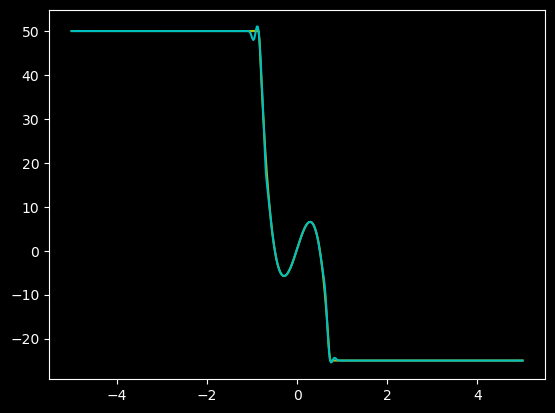

In [2]:
analytic = mpemba.special_potentials.AnalyticAsymmetricDoubleWellPotential(E_tilt=0.4, force_asymmetry=0.5, n=2, n2=5, x_min=-5, x_max=5)
x = np.linspace(-5, 5, 500)
analytic.comparisonPotential.plot_force(plot_range=x, color='y')
analytic.plot_force(plot_range=x)

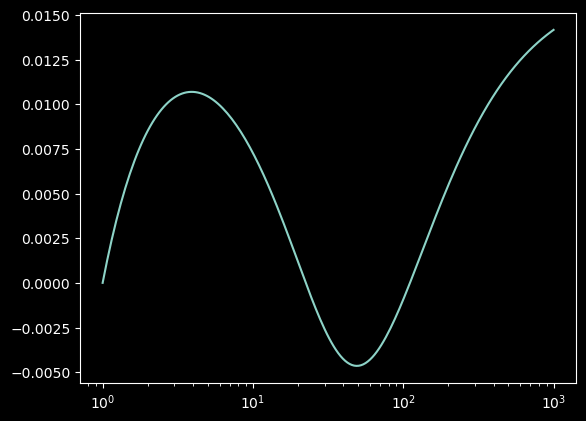

In [42]:
analytic.comparisonPotential.plot_a_2s(k_BT_max=1000)

In [44]:
U = analytic.comparisonPotential.U(x)
U_approx = analytic.U(x)
F = analytic.comparisonPotential.F(x)
F_approx = analytic.F(x)

Ts = np.logspace(0, np.log10(1000), len(x))
a_2s = analytic.comparisonPotential.a_k_boltzmannIC(x=x, k_BT=Ts)
a_2s_approx = analytic.comparisonPotential.a_k_boltzmannIC(x=x, k_BT=Ts)

df = pd.DataFrame(np.array([U, U_approx, F, F_approx, Ts, a_2s, a_2s_approx]).T, columns = ['U', 'Ua', 'F', 'Fa', 'T', 'a2', 'a2a'], index=x)
df.index.name='x'
df.to_csv("analytic_params.csv")

In [4]:
ensemble = mpemba.construct_simulated_ensemble(analytic, k_BTs=[22,4,1], num_particles=10_000)

100%|██████████| 9999/9999 [00:29<00:00, 340.11it/s]


In [6]:
ensemble.export_distances("analytic_distances.csv")